# U.S. DOE H2O Wave Hindcast

Open-Source Data Resource Characterization Example

This examples shows how to use open source H2O hindcast resource
characterization data from a single marine energy site and perform a
high level wave energy resource analysis.

# Setup

In [1]:
import html
import inspect
from pathlib import Path

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib.ticker import MultipleLocator
from sklearn.mixture import GaussianMixture

from mhkit.wave import contours, graphics, performance
from mhkit.wave.io.hindcast import hindcast

from h2o_examples.mapping import render_sites_map_outputs

## Figure Setup

In [2]:
sns.set_theme()

# Save every figure to figures/<name>.png AND render inline. In a notebook plt.show()
# draws inline; as a script (Agg) show() is a no-op but the PNG is still written.
# figures/*.png is tracked with git-LFS (see .gitattributes) to keep the repo light.

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)


def savefig(name):
    plt.gcf().savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_wave_matrix(matrix, zlabel, figsize=(8, 8), fmt=".2f", buffer=1):
    """Heatmap of a sea-state matrix (Te on columns, Hm0 on the index).

    Empty bins are blanked and the axes are cropped to the populated bins plus a
    one-bin `buffer` on each side. Light minor gridlines fall on the bin edges.
    Adapted from the EMEC/PacWave proficiency-testing capture-matrix plot.
    """
    m = matrix.replace(0, np.nan)

    # Crop to populated bins + a one-bin buffer, dropping the empty low-Te block.
    rows = np.where(m.notna().any(axis=1))[0]
    cols = np.where(m.notna().any(axis=0))[0]
    r0, r1 = max(rows.min() - buffer, 0), min(rows.max() + buffer, m.shape[0] - 1)
    c0, c1 = max(cols.min() - buffer, 0), min(cols.max() + buffer, m.shape[1] - 1)
    m = m.iloc[r0 : r1 + 1, c0 : c1 + 1].sort_index(ascending=False)  # Hm0 up

    plt.figure(figsize=figsize)
    ax = sns.heatmap(
        m, annot=True, fmt=fmt, cmap="viridis", cbar_kws={"label": zlabel}
    )
    # Minor ticks sit on the bin edges (between the centered cells) -> grid there.
    ax.grid(False)
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(MultipleLocator(1.0))
    ax.yaxis.set_minor_locator(MultipleLocator(1.0))
    ax.grid(which="minor", color="#dddddd", linewidth=0.6)
    ax.set_xlabel("Energy Period, $T_e$ [s]")
    ax.set_ylabel("Significant Wave Height, $H_{m0}$ [m]")
    plt.tight_layout()
    return ax

# Wave Energy Test Sites

In [3]:
def centerpoint(corners):
    return {
        "lat": float(np.mean([corner["lat"] for corner in corners.values()])),
        "lng": float(np.mean([corner["lng"] for corner in corners.values()])),
    }


# Sites keyed by name -> {"lat": latitude, "lng": longitude, "label": short label}.
# PacWave sites also retain their original corners and calculate lat/lng from them.
# Run one now; loop later for multiple sites.
SITES = {
    # https://oregonstate.app.box.com/s/w9akpvhpev03mv4sqotl0vzm2dgk5xdq
    # PACWAVE SOUTH WAVE ENERGY
    # TEST SITE Testing Wave Energy for the Future
    # PacWave is an open ocean, wave energy testing facility at Oregon State University. It consists
    # of two sites, each located within several miles of the deep water commercial port of Newport,
    # Oregon. PacWave South is an in-development, state-of-the-art, pre-permitted, accredited,
    # grid- connected wave energy test facility; developed in partnership with the US Department of
    # Energy, the State of Oregon and local stakeholders. Construction started in 2021 and will be
    # completed in 2024, with testing starting in 2025.
    # SITE SPECIFICATIONS
    # • Number of berths: 4
    # • Location of Test Site: 6 nautical miles off the coast of Newport Oregon
    # • Depth of site: 65-78 meters MLLW
    # • Site coordinates:
    # NW: 44º 35’ 00.00”N 124º 14’ 30.00”W
    # NE: 44º 35’ 02.75”N 124º 13’ 06.17”W
    # SE: 44º 33’ 02.75”N 124º 12’ 58.51”W
    # SW: 44º 33’ 00.00”N 124º 14’ 22.41”W
    # • Nature of seabed: Soft, sandy bottom
    # • Wave data facilities: Waverider buoys, Spotter buoys, or similar
    # • Mean annual wave power density: 40 kW/m, varies with year and location
    # • Wave periods: 5-17s
    # • Prevailing wave direction: WNW
    # • Sea states: The majority of sea states are within the range of:
    # 1m < Hm0 < 3.5m and 7s < Te < 11s,
    # including extreme sea states caused by severe storms where Hm0 exceeded 7.5m.
    # • Environmental site characterization data
    # • Meteorological data
    # • Technical capacity: data acquisition, rated export capacity of berths:
    # 20MW Connection Voltage: 12.47kV to CLPUD, berths configurable up to 30kV
    # • Site access nearest port: Newport and Toledo portofnewport.com portoftoledo.org
    # • Support Facilities: Berthing & working areas, office facilities, boatyard
    # • Grid Connection: Metered at point of connection to the Central Lincoln People’s Utility Distric
    "US_Oregon_PacWave_South": {
        "label": "PacWave South",
        "color": "steelblue",
        "corners": {
            # NW: 44º 35’ 00.00”N 124º 14’ 30.00”W
            # https://www.google.com/maps/place/44%C2%B035'00.0%22N+124%C2%B014'30.0%22W/@44.5833333,-124.2416667,1231m/data=!3m2!1e3!4b1!4m4!3m3!8m2!3d44.5833333!4d-124.2416667?entry=ttu&g_ep=EgoyMDI2MDcxMi4wIKXMDSoASAFQAw%3D%3D
            "Northwest Corner": {"lat": 44.583333, "lng": -124.241667},
            # NE: 44º 35’ 02.75”N 124º 13’ 06.17”W
            # https://www.google.com/maps/place/44%C2%B035'02.8%22N+124%C2%B013'06.2%22W/@44.5840972,-124.2183806,1231m/data=!3m2!1e3!4b1!4m4!3m3!8m2!3d44.5840972!4d-124.2183806?entry=ttu&g_ep=EgoyMDI2MDcxMi4wIKXMDSoASAFQAw%3D%3D
            # Northeast Corner: (44.584097, -124.218381)
            "Northeast Corner": {"lat": 44.584097, "lng": -124.218381},
            # SW: 44º 33’ 00.00”N 124º 14’ 22.41”W
            # https://www.google.com/maps/place/44%C2%B033'00.0%22N+124%C2%B014'22.4%22W/@44.5507677,-124.2188277,1232m/data=!3m1!1e3!4m4!3m3!8m2!3d44.55!4d-124.2395583?entry=ttu&g_ep=EgoyMDI2MDcxMi4wIKXMDSoASAFQAw%3D%3D
            "Southwest Corner": {"lat": 44.550764, "lng": -124.216253},
            # SE: 44º 33’ 02.75”N 124º 12’ 58.51”W
            # https://www.google.com/maps/place/44%C2%B033'02.8%22N+124%C2%B012'58.5%22W/@44.5507677,-124.2188277,1232m/data=!3m2!1e3!4b1!4m4!3m3!8m2!3d44.5507639!4d-124.2162528?entry=ttu&g_ep=EgoyMDI2MDcxMi4wIKXMDSoASAFQAw%3D%3D
            "Southeast Corner": {"lat": 44.550000, "lng": -124.239558},
        },
    },
    # PACWAVE NORTH WAVE ENERGY
    # TEST SITE
    # SITE SPECIFICATIONS
    # Testing Wave Energy for the Future
    # PacWave is an open ocean wave energy testing facility at Oregon State University. It consists
    # of two sites, each located within several miles of the deep-water commercial port of Newport,
    # Oregon. PacWave North is an established autonomous test site for small-scale, prototype, and
    # maritime market technologies. PacWave North offers a site in state waters with streamlined
    # permitting; expected time to permit is under one year. The site is shallower than PacWave
    # South and closer to port. PacWave North is a persistently monitored site (wave, metocean
    # measurements, and habitat surveys).
    # • Flexible number of berths
    # • Located 2 nautical miles off the coastline
    # • Depth is 45-55 meters MLLW
    # • Site Coordinates:
    # NW: 44º 41’ 52.08”N 124º 08’ 46.32”W
    # NE: 44º 41’ 54.96”N 124º 07’ 22.44”W
    # SE: 44º 40’ 54.84”N 124º 07’ 18.48”W
    # SW: 44º 40’ 52.32”N 124º 08’ 42.72”W
    # • Seabed has a soft, sandy bottom
    # • Mean annual wave power density is 40kW/m,
    # variable with year/location
    # • Wave data facilities include Waverider
    # or similar buoys
    # • Wave periods are 5-17s
    # • Prevailing Wave Direction is WNW
    # • The majority of sea states are within the
    # range of:
    # 1m < H m0 < 3.5m and 7s < T e < 11s @ wvw
    # including extreme sea states caused by
    # severe storms where H m0 exceeded 7.5m
    # NW: 44º 41’ 52.08”N 124º 08’ 46.32”W
    # https://www.google.com/maps/place/44%C2%B041'52.1%22N+124%C2%B008'46.3%22W/@44.6978038,-124.1487749,1229m/data=!3m2!1e3!4b1!4m4!3m3!8m2!3d44.6978!4d-124.1462?entry=ttu&g_ep=EgoyMDI2MDcxMi4wIKXMDSoASAFQAw%3D%3D
    "US_Oregon_PacWave_North": {
        "label": "PacWave North",
        "color": "#d62728",
        "corners": {
            # NW: 44º 41’ 52.08”N 124º 08’ 46.32”W
            # https://www.google.com/maps/place/44%C2%B041'52.1%22N+124%C2%B008'46.3%22W/@44.6978038,-124.1487749,1229m/data=!3m2!1e3!4b1!4m4!3m3!8m2!3d44.6978!4d-124.1462?entry=ttu&g_ep=EgoyMDI2MDcxMi4wIKXMDSoASAFQAw%3D%3D
            # Northwest Corner: (44.697800, -124.146200)
            "Northwest Corner": {"lat": 44.697800, "lng": -124.146200},
            # NE: 44º 41’ 54.96”N 124º 07’ 22.44”W
            # https://www.google.com/maps/place/44%C2%B041'55.0%22N+124%C2%B007'22.4%22W/@44.6978038,-124.1487749,1229m/data=!3m1!1e3!4m4!3m3!8m2!3d44.6986!4d-124.1229?entry=ttu&g_ep=EgoyMDI2MDcxMi4wIKXMDSoASAFQAw%3D%3D
            # Northeast Corner: (44.698600, -124.122900)
            "Northeast Corner": {"lat": 44.698600, "lng": -124.122900},
            # SE: 44º 40’ 54.84”N 124º 07’ 18.48”W
            # https://www.google.com/maps/search/44%C2%BA+40%E2%80%99+54.84%E2%80%9DN+124%C2%BA+07%E2%80%99+18.48%E2%80%9DW/@44.6986038,-124.1254749,1229m/data=!3m1!1e3?entry=ttu&g_ep=EgoyMDI2MDcxMi4wIKXMDSoASAFQAw%3D%3D
            # Southeast Corner: (44.681900, -124.121800)
            "Southeast Corner": {"lat": 44.681900, "lng": -124.121800},
            # SW: 44º 40’ 52.32”N 124º 08’ 42.72”W
            # https://www.google.com/maps/place/44%C2%B040'52.3%22N+124%C2%B008'42.7%22W/@44.6812038,-124.1477749,1229m/data=!3m2!1e3!4b1!4m4!3m3!8m2!3d44.6812!4d-124.1452?entry=ttu&g_ep=EgoyMDI2MDcxMi4wIKXMDSoASAFQAw%3D%3D
            # Southwest Corner: (44.681200, -124.145200)
            "Southwest Corner": {"lat": 44.681200, "lng": -124.145200},
        },
    },
    # Azura Deployment Site: https://en.wikipedia.org/wiki/Azura_(wave_power_device)
    "US_Hawaii_Oahu_WETS": {
        "lat": 21.46488,
        "lng": -157.751524,
        "label": "WETS",
    },
    # HERO WEC: https://modaq.nlr.gov/hero-wec-dashboard/?tab=location
    "US_North_Carolina_Jenettes_Pier": {
        "lat": 35.91036,
        "lng": -75.59239,
        "label": "Jennette's Pier",
    },
    # https://tethys-engineering.pnnl.gov/sites/default/files/publications/Coe-et-al-2023.pdf
    "US_Massachusetts_WoodsHole_PioneerWec": {
        "lat": 35.943117,
        "lng": -74.88035,
        "label": "Pioneer WEC",
    },
    # CalWave Deployment: https://mhkdr.openei.org/files/322/CalWave_IOM_Revised.pdf
    "US_California_Scripps_Pier": {
        "lat": 32.867633,
        "lng": -117.263167,
        "label": "Scripps Pier",
    },
    # Best Guess
    # https://www.google.com/maps/@35.163837,-120.7279724,5653m/data=!3m1!1e3?entry=ttu&g_ep=EgoyMDI2MDcxMi4wIKXMDSoASAFQAw%3D%3D
    "US_California_San_Luis_Obispo": {
        "lat": 35.1672960606959,
        "lng": -120.740349224586,
        "label": "San Luis Obispo",
    },
}

for site in SITES.values():
    if "corners" in site:
        site.update(centerpoint(site["corners"]))


def site_lat_lng(site):
    return (site["lat"], site["lng"])


def make_sites_map(sites):
    center = [
        np.mean([site["lat"] for site in sites.values()]),
        np.mean([site["lng"] for site in sites.values()]),
    ]
    site_map = folium.Map(location=center, zoom_start=4)

    for site in sites.values():
        if "corners" in site:
            add_site_bounds(site_map, site)

    for site in sites.values():
        folium.Marker(
            location=[site["lat"], site["lng"]],
            tooltip=site["label"],
        ).add_to(site_map)
        add_site_label(site_map, site)
    return site_map


def add_site_label(site_map, site):
    label = html.escape(site["label"])
    folium.Marker(
        location=[site["lat"], site["lng"]],
        icon=folium.DivIcon(
            icon_size=(150, 24),
            icon_anchor=(-8, 18),
            class_name="site-label",
            html=f"""
            <div style="
                color: #111827;
                font-size: 12px;
                font-weight: 600;
                line-height: 1.2;
                white-space: nowrap;
                text-shadow: -1px -1px 0 white, 1px -1px 0 white,
                             -1px 1px 0 white, 1px 1px 0 white;
                pointer-events: none;
            ">{label}</div>
            """,
        ),
    ).add_to(site_map)


def add_site_bounds(site_map, site):
    color = site["color"]
    bounds = [
        [corner["lat"], corner["lng"]] for corner in ordered_corners(site["corners"])
    ]
    folium.Polygon(
        locations=bounds,
        color=color,
        weight=2,
        fill=True,
        fill_color=color,
        fill_opacity=0.18,
        tooltip=folium.Tooltip(site["label"], permanent=False),
    ).add_to(site_map)


def ordered_corners(corners):
    ordered = sorted(corners.values(), key=lambda corner: corner["lat"], reverse=True)
    north = sorted(ordered[:2], key=lambda corner: corner["lng"])
    south = sorted(ordered[2:], key=lambda corner: corner["lng"], reverse=True)
    return [*north, *south]


def render_sites_map(sites, output_dir, context=None):
    render_sites_map_outputs(
        sites,
        make_sites_map,
        output_dir=output_dir,
        stem="sites_map",
        context=context,
    )
    return make_sites_map(sites)


### Test Sites Map

In [4]:
sites_map = render_sites_map(SITES, FIG_DIR)

Make this Notebook Trusted to load map: File -> Trust Notebook <iframe srcdoc="<!DOCTYPE html>
<html>
<head>
 
 <meta http-equiv="content-type" content="text/html; charset=UTF-8" />
 <script src="https://cdn.jsdelivr.net/npm/leaflet@1.9.3/dist/leaflet.js"></script>
 <script src="https://code.jquery.com/jquery-3.7.1.min.js"></script>
 <script src="https://cdn.jsdelivr.net/npm/bootstrap@5.2.2/dist/js/bootstrap.bundle.min.js"></script>
 <script src="https://cdnjs.cloudflare.com/ajax/libs/Leaflet.awesome-markers/2.0.2/leaflet.awesome-markers.js"></script>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/leaflet@1.9.3/dist/leaflet.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/bootstrap@5.2.2/dist/css/bootstrap.min.css"/>
 <link rel="stylesheet" href="https://netdna.bootstrapcdn.com/bootstrap/3.0.0/css/bootstrap-glyphicons.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/@fortawesome/fontawesome-free@6.2.0/css/all.min.css"/>
 <link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/Leaflet.awesome-markers/2.0.2/leaflet.awesome-markers.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/gh/python-visualization/folium/folium/templates/leaflet.awesome.rotate.min.css"/>
 
 <meta name="viewport" content="width=device-width,
 initial-scale=1.0, maximum-scale=1.0, user-scalable=no" />
 <style>
 #map_267b1b83c36a51874e0cd383579272be {
 position: relative;
 width: 100.0%;
 height: 100.0%;
 left: 0.0%;
 top: 0.0%;
 }
 .leaflet-container { font-size: 1rem; }
 </style>

 <style>html, body {
 width: 100%;
 height: 100%;
 margin: 0;
 padding: 0;
 }
 </style>

 <style>#map {
 position:absolute;
 top:0;
 bottom:0;
 right:0;
 left:0;
 }
 </style>

 <script>
 L_NO_TOUCH = false;
 L_DISABLE_3D = false;
 </script>

 
</head>
<body>
 
 
 <div class="folium-map" id="map_267b1b83c36a51874e0cd383579272be" ></div>
 
</body>
<script>
 
 
 var map_267b1b83c36a51874e0cd383579272be = L.map(
 "map_267b1b83c36a51874e0cd383579272be",
 {
 center: [35.80145850867084, -113.51296713922657],
 crs: L.CRS.EPSG3857,
 ...{
 "zoom": 4,
 "zoomControl": true,
 "preferCanvas": false,
}

 }
 );

 

 
 
 var tile_layer_f8cb03b2c3af3a60167e0def6f59e1f1 = L.tileLayer(
 "https://tile.openstreetmap.org/{z}/{x}/{y}.png",
 {
 "minZoom": 0,
 "maxZoom": 19,
 "maxNativeZoom": 19,
 "noWrap": false,
 "attribution": "\u0026copy; \u003ca href=\"https://www.openstreetmap.org/copyright\"\u003eOpenStreetMap\u003c/a\u003e contributors",
 "subdomains": "abc",
 "detectRetina": false,
 "tms": false,
 "opacity": 1,
}

 );
 
 
 tile_layer_f8cb03b2c3af3a60167e0def6f59e1f1.addTo(map_267b1b83c36a51874e0cd383579272be);
 
 
 var polygon_b3fb65562b09e2fa19e8b93b010dd46f = L.polygon(
 [[44.583333, -124.241667], [44.584097, -124.218381], [44.550764, -124.216253], [44.55, -124.239558]],
 {"bubblingMouseEvents": true, "color": "steelblue", "dashArray": null, "dashOffset": null, "fill": true, "fillColor": "steelblue", "fillOpacity": 0.18, "fillRule": "evenodd", "lineCap": "round", "lineJoin": "round", "noClip": false, "opacity": 1.0, "smoothFactor": 1.0, "stroke": true, "weight": 2}
 ).addTo(map_267b1b83c36a51874e0cd383579272be);
 
 
 polygon_b3fb65562b09e2fa19e8b93b010dd46f.bindTooltip(
 `<div>
 PacWave South
 </div>`,
 {
 "permanent": false,
 "sticky": true,
}
 );
 
 
 var polygon_961652cb76d5793686bfab4544d950b8 = L.polygon(
 [[44.6978, -124.1462], [44.6986, -124.1229], [44.6819, -124.1218], [44.6812, -124.1452]],
 {"bubblingMouseEvents": true, "color": "#d62728", "dashArray": null, "dashOffset": null, "fill": true, "fillColor": "#d62728", "fillOpacity": 0.18, "fillRule": "evenodd", "lineCap": "round", "lineJoin": "round", "noClip": false, "opacity": 1.0, "smoothFactor": 1.0, "stroke": true, "weight": 2}
 ).addTo(map_267b1b83c36a51874e0cd383579272be);
 
 
 polygon_961652cb76d5793686bfab4544d950b8.bindTooltip(
 `<div>
 PacWave North
 </div>`,
 {
 "permanent": false,
 "sticky": true,
}
 );
 
 
 var marker_f4c185f579f2cb4525750bfa5e141c8a = L.m

## Downloading Data

One request feeds every deliverable; `mean_wave_direction` (1-hour only)
drives directionality.

In [5]:
SELECTED_SITE = "US_Oregon_PacWave_South"
YEARS = [2010]
lat_lon = site_lat_lng(SITES[SELECTED_SITE])

In [6]:
hindcast_region = hindcast.region_selection(lat_lon)

PARAMS = [
    "significant_wave_height",
    "energy_period",
    "omni-directional_wave_power",
    "mean_wave_direction",
]
raw, metadata = hindcast.request_wpto_point_data("1-hour", PARAMS, lat_lon, YEARS)
data = raw.rename(
    columns={
        "significant_wave_height_0": "Hm0",
        "energy_period_0": "Te",
        "omni-directional_wave_power_0": "J",
        "mean_wave_direction_0": "Dir",
    }
)
data["J"] = data["J"] / 1000.0  # W/m -> kW/m
if hindcast_region == 'West_Coast':
    data["Dir"] = (data["Dir"] - 90.0) % 360.0  # correct -90 deg direction offset

## Exploring the Downloaded Data

### Metadata

In [7]:
metadata

### Data Preview

In [8]:
data.head()

## 1. Aggregate Statistics (percentile)

To calculate aggregate wave energy statistics we are going to use an
mhkit function in the wave module called `performance.statistics`. We
can print the docstring of the function using `inspect.getdoc`

In [9]:
print(inspect.getdoc(performance.statistics))

Calculates statistics, including count, mean, standard
deviation (std), min, percentiles (25%, 50%, 75%), and max.

Note that std uses a degree of freedom of N in accordance with
Formula D.5 of IEC TS 62600-100 Ed. 2.0 en 2024.

Parameters
------------
X: numpy array, pandas Series, pandas DataFrame, xarray DataArray, or xarray Dataset
    Data
to_pandas: bool (optional)
    Flag to output pandas instead of xarray. Default = True.

Returns
---------
stats: pandas Series or xarray DataArray
    Statistics

Now we plugin in the downloaded `data` into the `performance.statistics`
function

In [10]:
pd.DataFrame(
    {q: performance.statistics(data[q]) for q in ["Hm0", "Te", "J"]}
)

In [11]:
data[["Hm0", "Te", "J"]].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

## 2. Monthly Climatology

Box-and-whisker of the hourly distribution per month, and a daily median
with a 25th–75th percentile intraday band across the year.

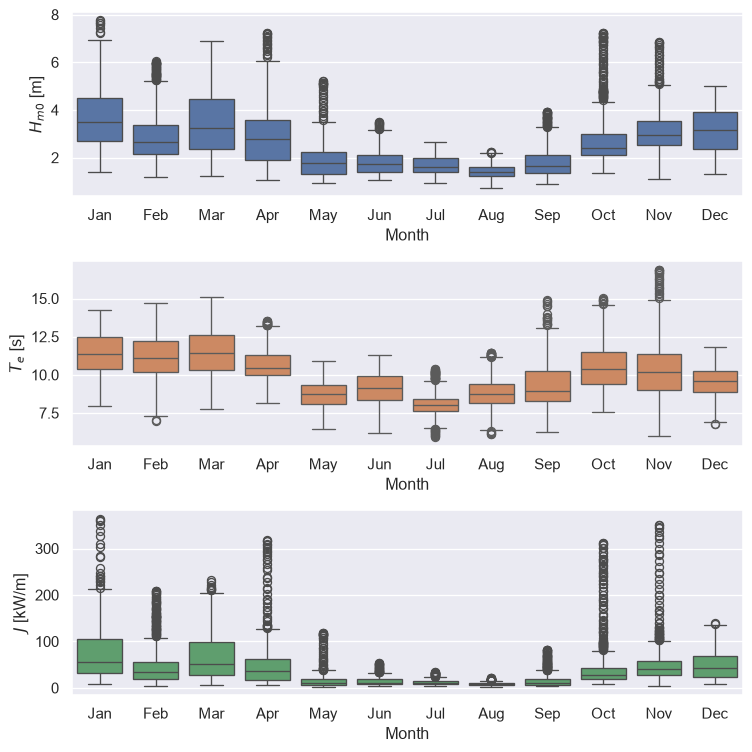

In [12]:
import calendar

QOIS = {"Hm0": "$H_{m0}$ [m]", "Te": "$T_e$ [s]", "J": "$J$ [kW/m]"}
months = np.arange(1, 13)
month_labels = [calendar.month_abbr[m] for m in months]  # 'Jan'..'Dec'
colors = sns.color_palette()  # default seaborn color cycle

fig, axes = plt.subplots(3, 1, figsize=(8, 8))
for i, (ax, (q, label)) in enumerate(zip(axes, QOIS.items())):
    sns.boxplot(x=data.index.month, y=data[q], ax=ax, color=colors[i])
    ax.set(xlabel="Month", ylabel=label)
    ax.set_xticks(range(12))
    ax.set_xticklabels(month_labels)
fig.tight_layout()
savefig("monthly_boxplot")

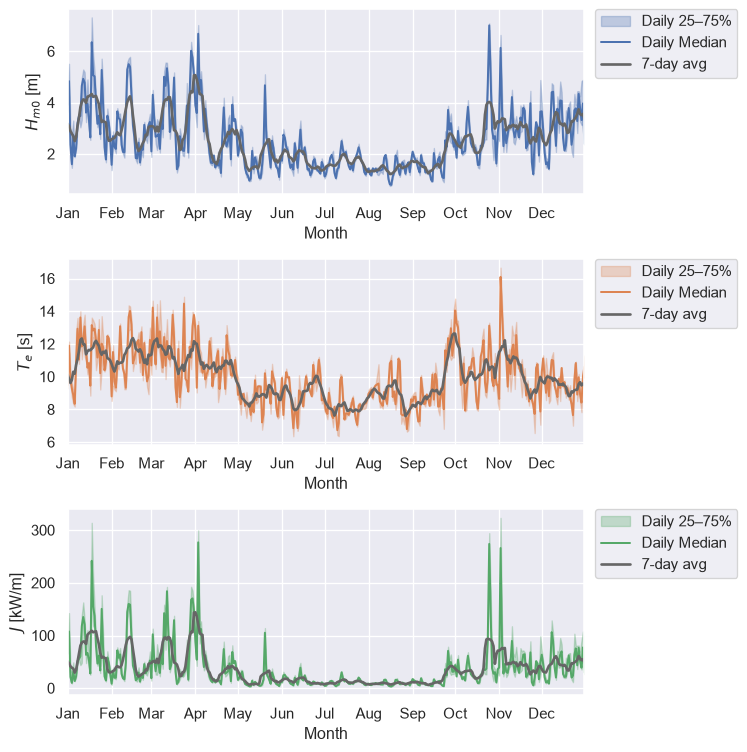

In [13]:
doy = data.index.dayofyear
dgrp = data.groupby(doy)
month_starts = [pd.Timestamp(YEARS[0], m, 1).dayofyear for m in months]

fig, axes = plt.subplots(3, 1, figsize=(8, 8))
for i, (ax, (q, label)) in enumerate(zip(axes, QOIS.items())):
    stats = dgrp[q].describe()
    days = stats.index
    ax.fill_between(
        days,
        stats["25%"],
        stats["75%"],
        color=colors[i],
        alpha=0.3,
        label="Daily 25–75%",
    )
    ax.plot(days, stats["50%"], color=colors[i], label="Daily Median")
    roll = stats["50%"].rolling(7, center=True, min_periods=1).mean()
    ax.plot(days, roll, color="0.4", linewidth=2, label="7-day avg")
    ax.set(xlabel="Month", ylabel=label)
    ax.margins(x=0)
    ax.set_xticks(month_starts)
    ax.set_xticklabels(month_labels)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
fig.tight_layout()
savefig("daily_climatology")

7-day moving average of the daily median, per variable.

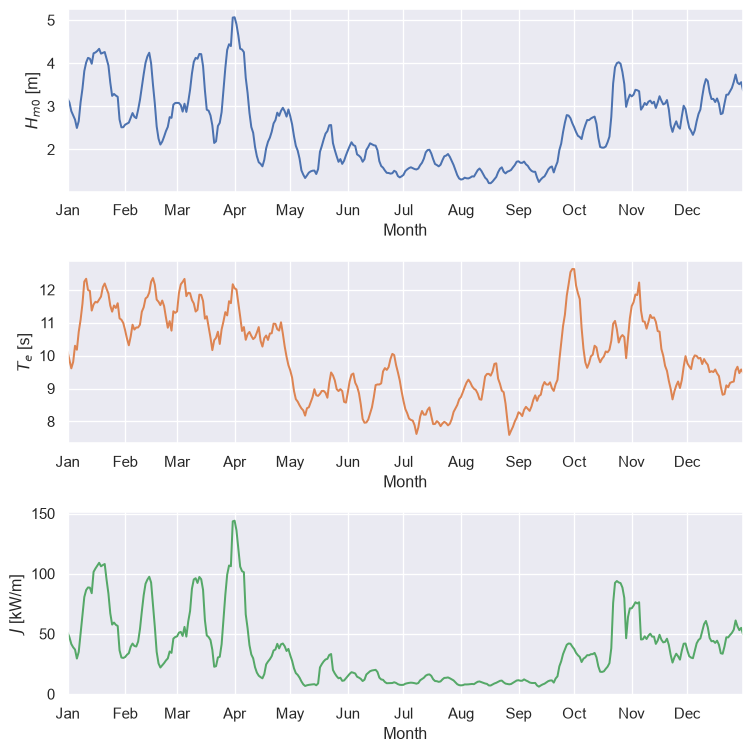

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8))
for i, (ax, (q, label)) in enumerate(zip(axes, QOIS.items())):
    roll = dgrp[q].median().rolling(7, center=True, min_periods=1).mean()
    ax.plot(roll.index, roll, color=colors[i], label="7-day avg")
    ax.set(xlabel="Month", ylabel=label)
    ax.margins(x=0)
    ax.set_xticks(month_starts)
    ax.set_xticklabels(month_labels)
fig.tight_layout()
savefig("weekly_average")

## 3. Joint Probability Distribution

Joint probability distribution (percent of the year) over the ($H_{m0}$,
$T_e$) sea-state bins.

In [15]:
Hm0_bins = np.arange(0, np.ceil(data.Hm0.max()) + 0.5, 0.5)
Te_bins = np.arange(0, np.ceil(data.Te.max()) + 1, 1)

# Joint probability of occurrence (reused as the AEP frequency matrix below).
frequency = performance.wave_energy_flux_matrix(
    data.Hm0, data.Te, data.J, "frequency", Hm0_bins, Te_bins
)
frequency

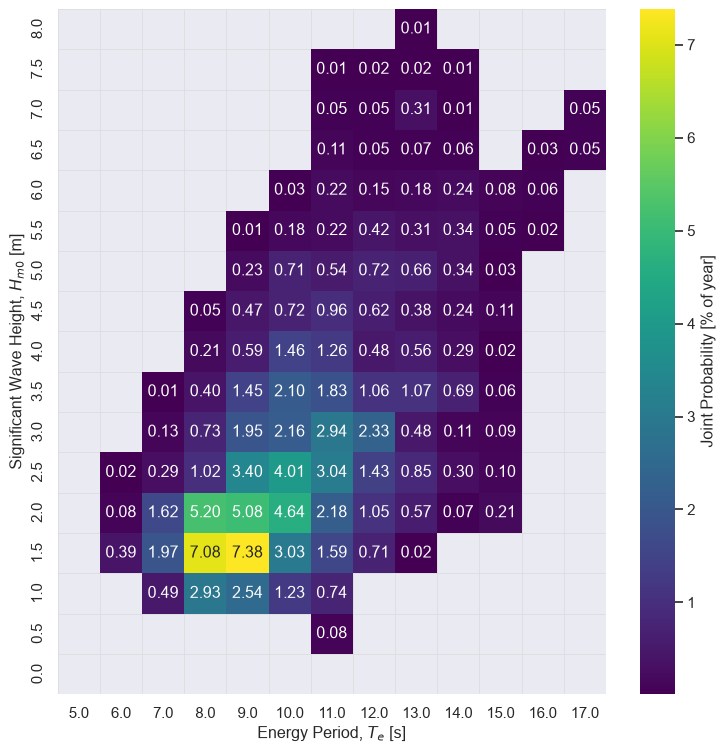

In [16]:
# Percent of the year each sea state occurs (frequency sums to 1 -> ×100 = %).
frequency_pct = frequency * 100

plot_wave_matrix(
    frequency_pct, zlabel="Joint Probability [% of year]"
)


savefig("jpd_frequency_matrix")

## 4. Extreme Sea States

Fifty- and one-hundred-year environmental contours bound the extreme sea
states a device must survive. MHKiT’s `contours.environmental_contours`
implements the principal-component-analysis (PCA) method adapted from
the Wave Energy Converter Design Response Toolbox (WDRT).
Environmental-contour methodology is an active research area, so results
vary with the approach and with the length of the input record — a
single hindcast year is illustrative here, not a formal extreme-value
estimate.

Coe, Ryan, Michelen, Carlos, Eckert-Gallup, Aubrey, Yu, Yi-Hsiang, and
Van Rij, Jennifer. (2016, March 30). WEC Design Response Toolbox v. 1.0
(Version 00) \[Computer software\].
https://www.osti.gov//servlets/purl/1312743.

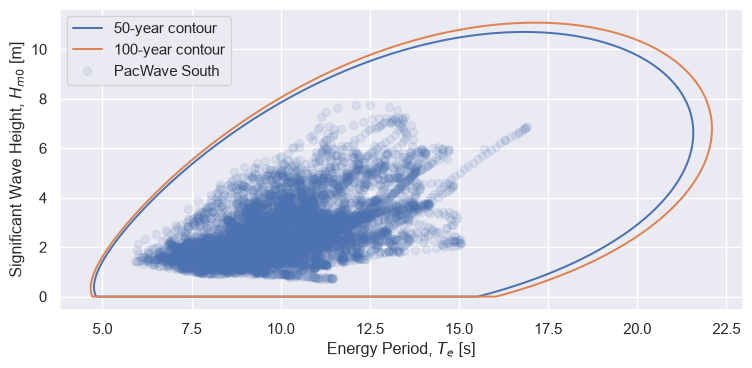

In [17]:
# Seconds between sea-state samples (1-hour hindcast -> 3600 s).
dt = (data.index[1] - data.index[0]).total_seconds()

copulas50 = contours.environmental_contours(data.Hm0, data.Te, dt, 50, method="PCA")
copulas100 = contours.environmental_contours(data.Hm0, data.Te, dt, 100, method="PCA")

Hm0_contours = [copulas50["PCA_x1"], copulas100["PCA_x1"]]
Te_contours = [copulas50["PCA_x2"], copulas100["PCA_x2"]]

fig, ax = plt.subplots(figsize=(8, 4))
graphics.plot_environmental_contour(
    data.Te.values,
    data.Hm0.values,
    Te_contours,
    Hm0_contours,
    data_label=SITES[SELECTED_SITE]["label"],
    contour_label=["50-year contour", "100-year contour"],
    x_label="Energy Period, $T_e$ [s]",
    y_label="Significant Wave Height, $H_{m0}$ [m]",
    ax=ax,
)
ax.legend(loc="upper left")
fig.tight_layout()
savefig("extreme_contours")

In [18]:
# Peak of each contour: the largest H_m0 and the T_e it occurs at.
for label, cop in (("50-year", copulas50), ("100-year", copulas100)):
    i = cop["PCA_x1"].argmax()
    print(f"{label}: H_m0 max {cop['PCA_x1'].max():.1f} m at T_e {cop['PCA_x2'][i]:.1f} s")

50-year: H_m0 max 10.7 m at T_e 16.9 s
100-year: H_m0 max 11.1 m at T_e 17.1 s

## 5. Representative Sea State Clusters

Simulating a wave energy converter against every hourly sea state is
intractable, so WEC design optimization uses a limited number of
*representative* sea states. A Gaussian-mixture model (GMM) — a more
general form of k-means — groups the ($T_e$, $H_{m0}$) sea states into
clusters and locates a representative center for each, following the
density of the data. We fit increasing cluster counts (4, 8, 16, 32,
64); more clusters capture the resource more faithfully at the cost of
more simulations.

The source buoy example next reconstructed each cluster’s energy from a
JONSWAP spectrum to compare against the total resource energy. That step
needs spectral frequency bins, which the bulk-parameter hindcast does
not provide, so it is omitted here.

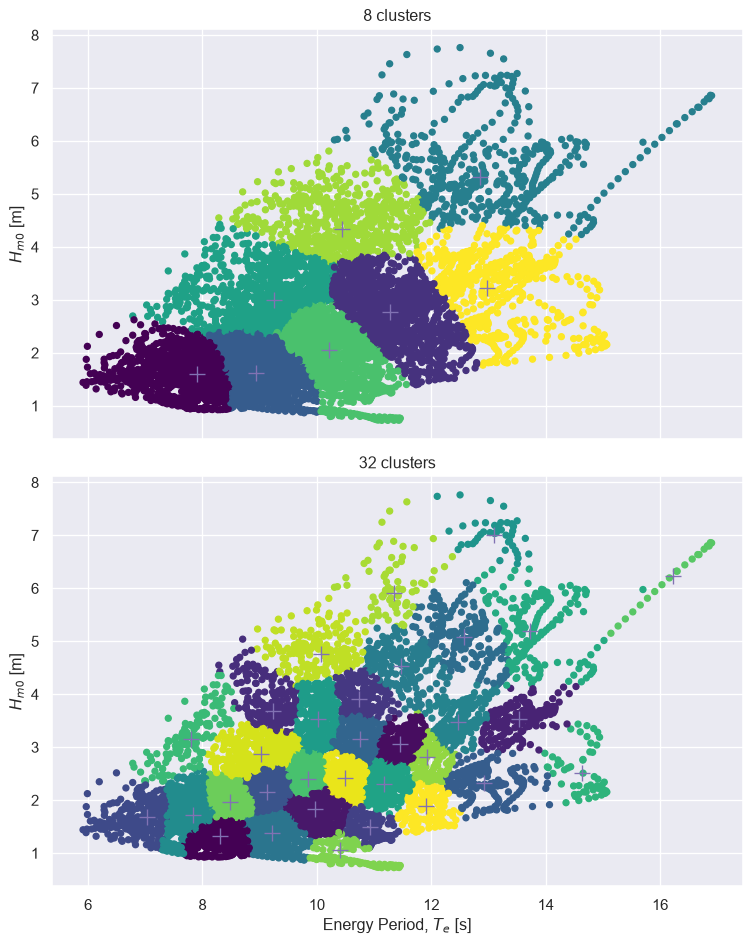

In [19]:
cluster_counts = [8, 32]
X = np.vstack((data.Te.values, data.Hm0.values)).T

fig, axs = plt.subplots(len(cluster_counts), 1, figsize=(8, 10), sharex=True)
for ax, n in zip(axs, cluster_counts):
    # random_state fixes the fit so renders are reproducible.
    gmm = GaussianMixture(n_components=n, random_state=0).fit(X)
    labels = gmm.predict(X)
    centers = gmm.means_  # columns: Te, Hm0
    ax.scatter(data.Te.values, data.Hm0.values, c=labels, s=20, cmap="viridis")
    ax.plot(centers[:, 0], centers[:, 1], "m+", markersize=12)
    ax.set(title=f"{n} clusters", ylabel="$H_{m0}$ [m]")
axs[-1].set_xlabel("Energy Period, $T_e$ [s]")
fig.tight_layout()
savefig("sea_state_clusters")

## 6. Exceedance Probability

Empirical survival function $P(H_{m0} > x)$.

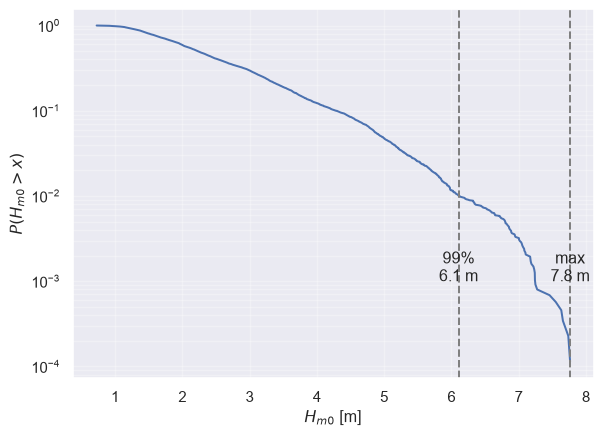

In [20]:
hm0_sorted = np.sort(data.Hm0.values)
exceedance = 1.0 - np.arange(1, hm0_sorted.size + 1) / (hm0_sorted.size + 1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogy(hm0_sorted, exceedance)
for pct in (0.99, 1.0):
    val = np.quantile(data.Hm0, pct) if pct < 1.0 else data.Hm0.max()
    ax.axvline(val, ls="--", color="0.5")
    ax.text(val, 1e-3, f"{'max' if pct == 1.0 else '99%'}\n{val:.1f} m", ha="center")
ax.set(xlabel="$H_{m0}$ [m]", ylabel="$P(H_{m0} > x)$")
ax.grid(True, which="both", alpha=0.3)
savefig("exceedance_hm0")

## 7. Directionality

Direction (θ) vs $H_{m0}$, $T_e$, and wave power, colored by joint
probability distribution (% of year); plus mean wave power by direction
sector.

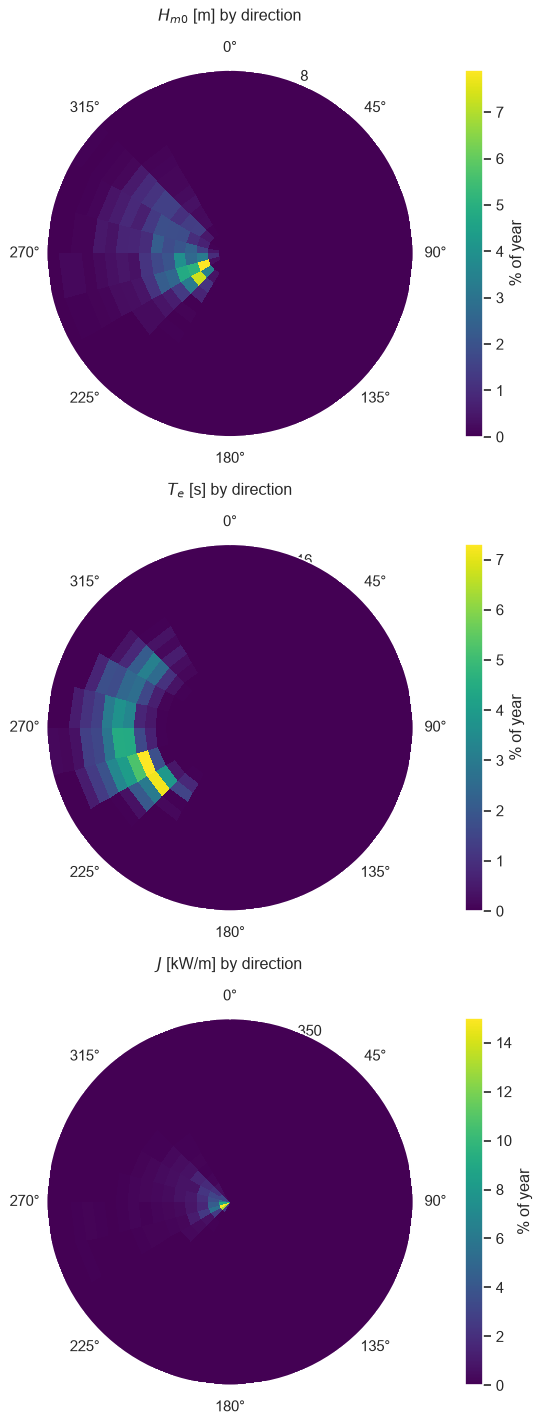

In [21]:
Dir_bins = np.arange(0, 360 + 15, 15)


def polar_jpd(ax, radius, r_bins, r_label):
    counts, _, _ = np.histogram2d(data.Dir, radius, bins=[Dir_bins, r_bins])
    counts = counts / counts.sum() * 100  # % of year per (direction, radius) bin
    th, rr = np.meshgrid(np.deg2rad(Dir_bins), r_bins, indexing="ij")
    pcm = ax.pcolormesh(th, rr, counts, shading="auto", cmap="viridis")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_title(r_label, pad=15)
    plt.colorbar(pcm, ax=ax, label="% of year", pad=0.1)


fig, axes = plt.subplots(
    3, 1, figsize=(6, 15), subplot_kw={"projection": "polar"}
)
polar_jpd(axes[0], data.Hm0, Hm0_bins, "$H_{m0}$ [m] by direction")
polar_jpd(axes[1], data.Te, Te_bins, "$T_e$ [s] by direction")
polar_jpd(axes[2], data.J, np.linspace(0, data.J.max(), len(Hm0_bins)), "$J$ [kW/m] by direction")
fig.tight_layout()
savefig("directionality_polar_jpd")

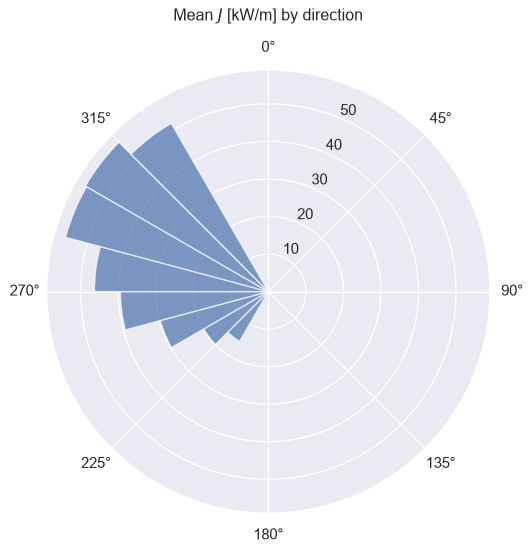

In [22]:
# Mean wave power per direction sector.
sector = pd.cut(data.Dir, Dir_bins)
mean_J = data.J.groupby(sector, observed=False).mean()
centers = np.deg2rad(Dir_bins[:-1] + 7.5)

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"})
ax.bar(centers, mean_J.fillna(0).values, width=np.deg2rad(15), alpha=0.7)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_title("Mean $J$ [kW/m] by direction", pad=15)
savefig("directionality_mean_power")

## 8. Multiple Sites: Comparison

The single-site pipeline above characterizes one location; here we place
several sites side by side. Edit `SITES_TO_COMPARE` — a plain list of
`SITES` keys — to add or omit sites. The comparison only needs
`Hm0`/`Te`/`J`, pulled from the `1-hour` product;
`request_wpto_point_data` caches each response to disk, so re-runs skip
HSDS. Every site keeps one color (from Matplotlib’s `tab10`) across all
four figures.

Several `SITES` are unavailable through the point-data API and are
commented out below: the very nearshore pier locations fall outside the
hindcast domain, and Hawaii has no data in this product. (The
fuller-coverage `3-hour` grid would reach some of them, but its
700k-node metadata exceeds the free NLR developer key’s HSDS limits.)
The loop also skips-with-a-warning on any request that fails, so the
figures render from whatever is available.

In [23]:
SITES_TO_COMPARE = [
    "US_Oregon_PacWave_South",
    "US_Oregon_PacWave_North",
    "US_California_San_Luis_Obispo",
    # --- unavailable via 1-hour point data (see note above) ---
    # "US_Hawaii_Oahu_WETS",              # no Hawaii data in this product
    # "US_North_Carolina_Jenettes_Pier",  # outside the hindcast domain (nearshore)
    # "US_Massachusetts_WoodsHole_PioneerWec",  # outside the hindcast domain
    # "US_California_Scripps_Pier",        # outside the hindcast domain (nearshore)
]  # comment a key in/out to include/omit that site

COMPARE_PARAMS = [
    "significant_wave_height",
    "energy_period",
    "omni-directional_wave_power",
]


def load_site(name, years=YEARS):
    """1-hour Hm0/Te/J for one site (request_wpto_point_data caches to disk)."""
    lat_lon = site_lat_lng(SITES[name])
    raw, _ = hindcast.request_wpto_point_data("1-hour", COMPARE_PARAMS, lat_lon, years)
    df = raw.rename(
        columns={
            "significant_wave_height_0": "Hm0",
            "energy_period_0": "Te",
            "omni-directional_wave_power_0": "J",
        }
    )
    df["J"] = df["J"] / 1000.0  # W/m -> kW/m
    return df


site_data = {}
for name in SITES_TO_COMPARE:
    try:
        site_data[name] = load_site(name)
    except Exception as e:  # e.g. a site outside hindcast coverage
        print(f"skipping {name}: {type(e).__name__}: {e}")

# One color per site, shared across every figure below.
tab10 = plt.get_cmap("tab10")
site_colors = {name: tab10(i) for i, name in enumerate(site_data)}

{name: df.shape for name, df in site_data.items()}

{'US_Oregon_PacWave_South': (8748, 3),
 'US_Oregon_PacWave_North': (8748, 3),
 'US_California_San_Luis_Obispo': (8748, 3)}

### 7-day moving averages

A 7-day centered moving average of each hourly quantity smooths out
storm-scale noise and exposes the seasonal cycle. One line per site; the
legend sits outside the axes.

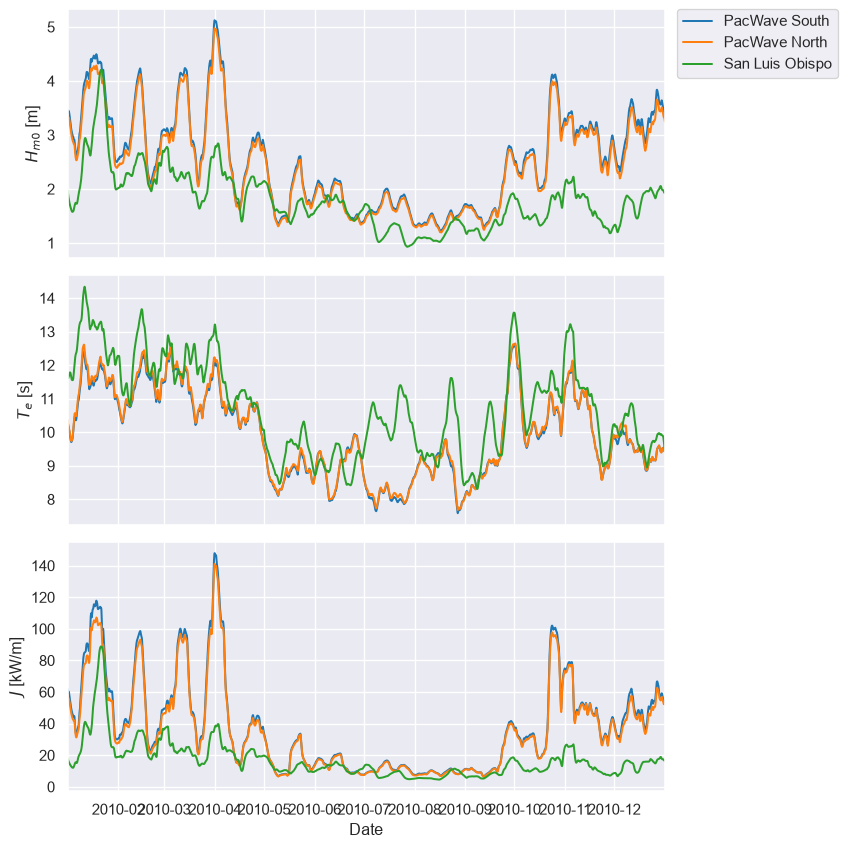

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
for ax, (q, ylabel) in zip(axes, QOIS.items()):
    for name, df in site_data.items():
        roll = df[q].rolling("7D", center=True, min_periods=1).mean()
        ax.plot(roll.index, roll, color=site_colors[name],
                label=SITES[name]["label"], linewidth=1.5)
    ax.set(ylabel=ylabel)
    ax.margins(x=0)
axes[-1].set_xlabel("Date")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
fig.tight_layout()
savefig("multisite_moving_average")

### 100-year contours

The 100-year environmental contours from Section 4, overlaid across
sites: each site’s hourly sea states appear as a light scatter, with its
PCA 100-year contour drawn in the same color. As in Section 4, a single
hindcast year is illustrative, not a formal extreme-value estimate.

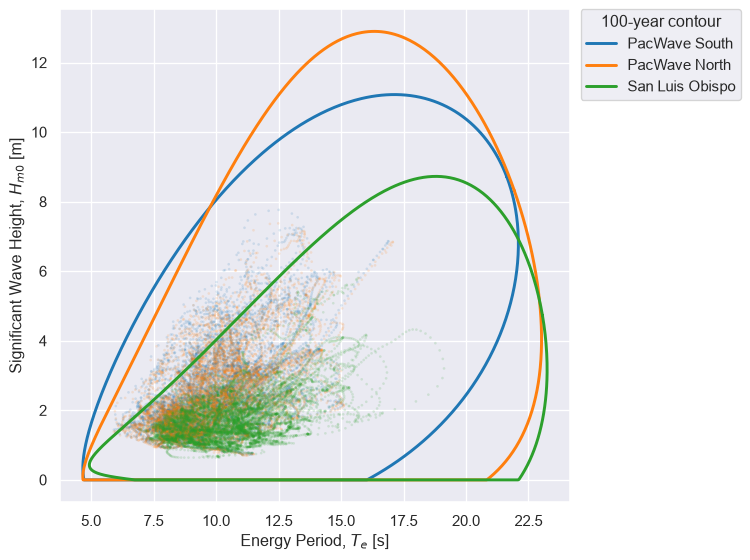

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, df in site_data.items():
    color = site_colors[name]
    dt = (df.index[1] - df.index[0]).total_seconds()  # 3600 s for 1-hour data
    ax.scatter(df.Te, df.Hm0, s=4, color=color, alpha=0.15, edgecolors="none")
    cop = contours.environmental_contours(df.Hm0, df.Te, dt, 100, method="PCA")
    ax.plot(cop["PCA_x2"], cop["PCA_x1"], color=color, linewidth=2.2,
            label=SITES[name]["label"])
ax.set(
    xlabel="Energy Period, $T_e$ [s]",
    ylabel="Significant Wave Height, $H_{m0}$ [m]",
)
ax.legend(title="100-year contour", loc="upper left",
          bbox_to_anchor=(1.02, 1), borderaxespad=0)
fig.tight_layout()
savefig("multisite_contour_100yr")